# Argument realization in an Ojibwe corpus: word order

In this notebook, we will attempt to parse the word order of overt nominals, currently touching 2 cases:
1. Transitive (Both arguments overt): Without splitting on specific attributes, what counts do we see of VOS, VSO, SVO etc.
2. One overt argument: For now just counting overall, will split on verb paradigm after.
3. Direct-inverse: Taking only 3-3 VTAs into account, what word orders do we see for the direct and inverse. 

In [1]:
# get the path to the .conllu treebank
from grammar_modules.disambiguation import REPO_ROOT
CORPUS_PATH = REPO_ROOT / "data" / "treebanks" / "Chi_mewinzha_full.conllu"

### Part 1: Transitive word order counts

Scan the `.conllu` file for word order information. 

In [2]:
from conllu import parse_incr

VSO_count = VOS_count = SVO_count = OVS_count = SOV_count = OSV_count = 0

# TODO: for now I only collect 1 subject and 1 object per sentence
#       and make sure that head matches. not good for embedded clauses etc.
with open(CORPUS_PATH, encoding="utf-8") as f:
    for i, sent in enumerate(parse_incr(f)):
        subjects = [] # list of tuples of ID, HEAD
        objects = [] # list of tuples of ID, HEAD

        for tok in sent:
            xpos = tok.get("xpos")
            if not xpos:
                continue
            # collect subjects and their head
            if tok["deprel"] == "nsubj":
                subj = (tok["id"], tok["head"])
                subjects.append(subj)
            # collect objects and their head
            if tok["deprel"] == "obj":
                obj = (tok["id"], tok["head"])
                objects.append(obj)

        # check that at least one subject and object are found
        if len(subjects) < 1 or len(objects) < 1:
            continue
        
        # build up subj/obj pairs where the head is the same ID
        subj_obj_pairs = []
        for subj in subjects:
            for obj in objects: 
                if subj[1] == obj[1]:
                    subj_obj_pairs.append((subj, obj))
        
        for subj, obj in subj_obj_pairs:
            # collect counts per case
            # VSO 
            if subj[0] > subj[1] and subj[0] < obj[0] and obj[0] > obj[1]:
                print(f"Sentence {i+1} is VSO: {sent.metadata.get("text")}")
                VSO_count += 1
                continue
            # VOS
            if subj[0] > subj[1] and subj[0] > obj[0] and obj[0] > obj[1]:
                print(f"Sentence {i+1} is VOS: {sent.metadata.get("text")}")
                VOS_count += 1
                continue
            # SVO 
            if subj[0] < subj[1] and obj[0] > obj[1]:
                print(f"Sentence {i+1} is SVO: {sent.metadata.get("text")}")
                SVO_count += 1
                continue
            # OVS 
            if subj[0] > subj[1] and obj[0] < obj[1]:
                print(f"Sentence {i+1} is OVS: {sent.metadata.get("text")}")
                OVS_count += 1
                continue
            # SOV 
            if subj[0] < subj[1] and subj[0] < obj[0] and obj[0] < obj[1]:
                print(f"Sentence {i+1} is SOV: {sent.metadata.get("text")}")
                SOV_count += 1
                continue
            # OSV 
            if subj[0] < subj[1] and subj[0] > obj[0] and obj[0] < obj[1]:
                print(f"Sentence {i+1} is OSV: {sent.metadata.get("text")}")
                OSV_count += 1
                continue

total_count = VSO_count + VOS_count + SVO_count + OVS_count + SOV_count + OSV_count
        
print(
    f"Total sentences w/ two overt arguments: {total_count}",
    f"Total VSO: {VSO_count}",
    f"Total VOS: {VOS_count}",
    f"Total SVO: {SVO_count}",
    f"Total OVS: {OVS_count}",
    f"Total SOV: {SOV_count}",
    f"Total OSV: {OSV_count}",
    sep="\n",
)


Sentence 28 is VSO: ingii-pizindawaag niin ingiw chi-aya'aag .
Sentence 32 is VSO: ingii-pizindawaag niin ingiw nichi-anishinaabemag .
Sentence 69 is SOV: gaawiin dash ge niin gegoo ingikendanziin , mashkiki gii-ozhitoowaad .
Sentence 70 is OVS: akina gegoo ogii-gikendaanaawaa mewinzha anishinaabeg .
Sentence 73 is OSV: miinawaa bagida'waawaad miinawaa iniw ayi'iing nibiikaang nimaamaa ondinaad iniw ayi'iin ozhitood ayi'iin apishimonan ozhitood .
Sentence 73 is SVO: miinawaa bagida'waawaad miinawaa iniw ayi'iing nibiikaang nimaamaa ondinaad iniw ayi'iin ozhitood ayi'iin apishimonan ozhitood .
Sentence 103 is OSV: miinawaa , mii iw apii anishinaabeg memoowaad i'iw mashkiki miinawaa iw wiigwaas .
Sentence 103 is SVO: miinawaa , mii iw apii anishinaabeg memoowaad i'iw mashkiki miinawaa iw wiigwaas .
Sentence 103 is SVO: miinawaa , mii iw apii anishinaabeg memoowaad i'iw mashkiki miinawaa iw wiigwaas .
Sentence 120 is OSV: akina gegoo wiinawaa ogii-ozhitoonaawaa .
Sentence 140 is SVO: gaaw

In [3]:
# create stats tables
import pandas as pd

stats = [
    {"word order": "VSO", "total": VSO_count,},
    {"word order": "VOS", "total": VOS_count,},
    {"word order": "SVO", "total": SVO_count,},
    {"word order": "OVS", "total": OVS_count,},
    {"word order": "SOV", "total": SOV_count,},
    {"word order": "OSV", "total": OSV_count,},
]
df = pd.DataFrame(stats)
df["ratio"] = round(df["total"] / total_count, 2)

print(df.to_string(index=False))

word order  total  ratio
       VSO      4   0.12
       VOS      1   0.03
       SVO     14   0.44
       OVS      6   0.19
       SOV      2   0.06
       OSV      5   0.16


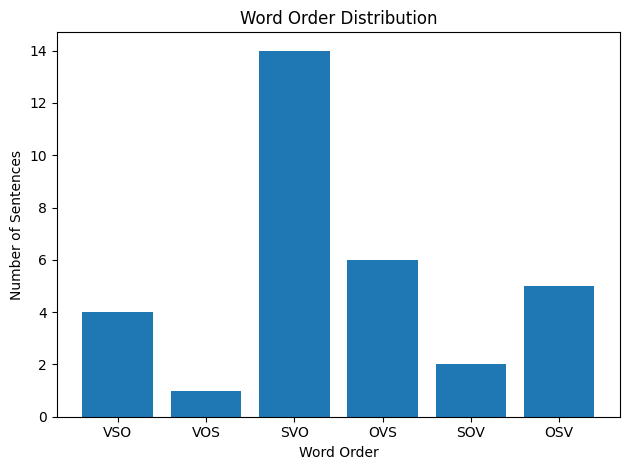

In [6]:
# Simple bar chart for word order distribution

import matplotlib.pyplot as plt
import numpy as np

# Data
orders = ["VSO", "VOS", "SVO", "OVS", "SOV", "OSV"]
totals = np.array([4, 1, 14, 6, 2, 5])

# Create plot
plt.figure()
plt.bar(orders, totals)

plt.xlabel("Word Order")
plt.ylabel("Number of Sentences")
plt.title("Word Order Distribution")

plt.tight_layout()
plt.show()


### Part 2: One overt argument word order

Similar logic to above, collect counts for different orders.

In [4]:
from conllu import parse_incr

VS_count = SV_count = VO_count = OV_count = 0

# TODO: here we collect more than 1 case per sentence
#       also still not splitting on verb paradigm
with open(CORPUS_PATH, encoding="utf-8") as f:
    for i, sent in enumerate(parse_incr(f)):
        subjects = [] # list of tuples of ID, HEAD
        objects = [] # list of tuples of ID, HEAD
        for tok in sent:
            xpos = tok.get("xpos")
            if not xpos:
                continue
            # collect subjects and their head
            if tok["deprel"] == "nsubj":
                subj = (tok["id"], tok["head"])
                subjects.append(subj)
            # collect objects and their head
            if tok["deprel"] == "obj":
                obj = (tok["id"], tok["head"])
                objects.append(obj)

        
        # collect counts per case
        for subj in subjects:
            if subj[0] > subj[1]:
                VS_count += 1
            elif subj[0] < subj[1]:
                SV_count += 1
        
        for obj in objects:
            if obj[0] > obj[1]:
                VO_count += 1
            elif obj[0] < obj[1]:
                OV_count += 1
        
print(
    f"Total VS: {VS_count}",
    f"Total SV: {SV_count}",
    f"Total VO: {VO_count}",
    f"Total OV: {OV_count}",
    sep="\n",
)


Total VS: 119
Total SV: 109
Total VO: 161
Total OV: 111


In [5]:
# create stats tables
import pandas as pd

stats = [
    {"word order": "VS", "total": VS_count,},
    {"word order": "SV", "total": SV_count,},
    {"word order": "VO", "total": VO_count,},
    {"word order": "OV", "total": OV_count,},
]
df = pd.DataFrame(stats)
print(df.to_string(index=False))

word order  total
        VS    119
        SV    109
        VO    161
        OV    111


### Part 3: Word order of direct and inverse

Sampling only VTA verbs, count word orders splitting on direct and inverse morphology.

In [ ]:
from conllu import parse_incr

VS_count = SV_count = VO_count = OV_count = 0

# TODO: here we collect more than 1 case per sentence
#       also still not splitting on verb paradigm
with open(CORPUS_PATH, encoding="utf-8") as f:
    for i, sent in enumerate(parse_incr(f)):
        subjects = [] # list of tuples of ID, HEAD
        objects = [] # list of tuples of ID, HEAD
        for tok in sent:
            xpos = tok.get("xpos")
            if not xpos:
                continue
            # collect subjects and their head
            if tok["deprel"] == "nsubj":
                subj = (tok["id"], tok["head"])
                subjects.append(subj)
            # collect objects and their head
            if tok["deprel"] == "obj":
                obj = (tok["id"], tok["head"])
                objects.append(obj)

        
        # collect counts per case
        for subj in subjects:
            if subj[0] > subj[1]:
                VS_count += 1
            elif subj[0] < subj[1]:
                SV_count += 1
        
        for obj in objects:
            if obj[0] > obj[1]:
                VO_count += 1
            elif obj[0] < obj[1]:
                OV_count += 1
        
print(
    f"Total VS: {VS_count}",
    f"Total SV: {SV_count}",
    f"Total VO: {VO_count}",
    f"Total OV: {OV_count}",
    sep="\n",
)
